# Deteção de Fraude em transações de Cartão de Crédito

Objetivo:

Criar modelo de Machine learning para detecção de fraudes

## Dicionário de dados

Fonte dos dados: [Kaggle](https://www.kaggle.com/mlg-ulb/creditcardfraud)

| Nome da coluna | Descrição             | Tipo de dado |
|----------------|-----------------------|--------------|
| `Time`         | Intervalo em segundos entre cada transação e a primeira | float     |
| `Vx`           | Resultado de PCA das variáveis originais | float   |
| `Amount`       | Valor de cada transação | float         |
| `Class`        | Classificação da transação entre genuína, 0, e fraudulenta, 1 | int        |

Na descrição da base de dados no Kaggle, são fornecidas algumas explicações acerca das variáveis:

- por questões de confidencialidade, não são disponibilizadas as identificações de boa
parte das variáveis originais;
- as representadas como V1, V2,... V28 são resultado de
uma transformação de análise de componentes principais - PCA, uma técnica utilizada para
condensar a informação contida em várias variáveis originais em um conjunto menor de
variáveis estatísticas (componentes) com uma perda mínima de informação. No trabalho
veremos algumas consequências dessa transformação em nossa análise;

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import DADOS_ORIGINAIS, DADOS_TRATADOS
from src.models import RANDOM_STATE

pd.set_option("display.max_columns", None, "float_format", "{:.2f}".format) 

sns.set_theme(palette="bright")

In [6]:
df = pd.read_csv(DADOS_ORIGINAIS, compression="zip")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [7]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.00,-11.88,10.07,-9.83,-2.07,-5.36,-2.61,-4.92,7.31,1.91,4.36,-1.59,2.71,-0.69,4.63,-0.92,1.11,1.99,0.51,-0.68,1.48,0.21,0.11,1.01,-0.51,1.44,0.25,0.94,0.82,0.77,0
284803,172787.00,-0.73,-0.06,2.04,-0.74,0.87,1.06,0.02,0.29,0.58,-0.98,-0.15,0.92,1.21,-0.68,1.16,-0.71,-0.03,-1.22,-1.55,0.06,0.21,0.92,0.01,-1.02,-0.61,-0.40,0.07,-0.05,24.79,0
284804,172788.00,1.92,-0.30,-3.25,-0.56,2.63,3.03,-0.30,0.71,0.43,-0.48,0.41,0.06,-0.18,-0.51,1.33,0.14,0.31,0.40,-0.58,0.00,0.23,0.58,-0.04,0.64,0.27,-0.09,0.00,-0.03,67.88,0
284805,172788.00,-0.24,0.53,0.70,0.69,-0.38,0.62,-0.69,0.68,0.39,-0.40,-1.93,-0.96,-1.04,0.45,1.96,-0.61,0.51,1.11,2.90,0.13,0.27,0.80,-0.16,0.12,-0.57,0.55,0.11,0.10,10.00,0
284806,172792.00,-0.53,-0.19,0.70,-0.51,-0.01,-0.65,1.58,-0.41,0.49,-0.92,-1.04,-0.03,-0.19,-0.08,0.04,-0.30,-0.66,0.17,-0.26,0.38,0.26,0.64,0.38,0.01,-0.47,-0.82,-0.00,0.01,217.00,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,1.09,1.02,1.00,1.00,0.96,0.92,0.88,0.85,0.84,0.81,0.77,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,-24.59,-4.80,-18.68,-5.79,-19.21,-4.50,-14.13,-25.16,-9.50,-7.21,-54.50,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,-0.54,-0.76,-0.41,-0.65,-0.43,-0.58,-0.47,-0.48,-0.50,-0.46,-0.21,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,-0.09,-0.03,0.14,-0.01,0.05,0.05,0.07,-0.07,-0.00,0.00,-0.06,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,0.45,0.74,0.62,0.66,0.49,0.65,0.52,0.40,0.50,0.46,0.13,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,23.75,12.02,7.85,7.13,10.53,8.88,17.32,9.25,5.04,5.59,39.42,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [10]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [18]:
#Coluna tempo
df["Time"].max() / 60 #minutos
df["Time"].max() / 60/ 60 #horas
df["Time"].max() / 60/ 60 / 24 #dias 2 dias de dados

np.float64(1.9999074074074075)

Análise Exploratória de Dados (EDA)
 - base com 284mil linhas e 31 colunas
 - Colunas V1 a V28 extraídas de um processamento de PCA para confidencializar informações confidenciais de clientes.
 - Não há linhas com valores nulos
 - Operações realizadas em um período de 2 dias, coluna tempo informa o tempo com relação a primeira transação.


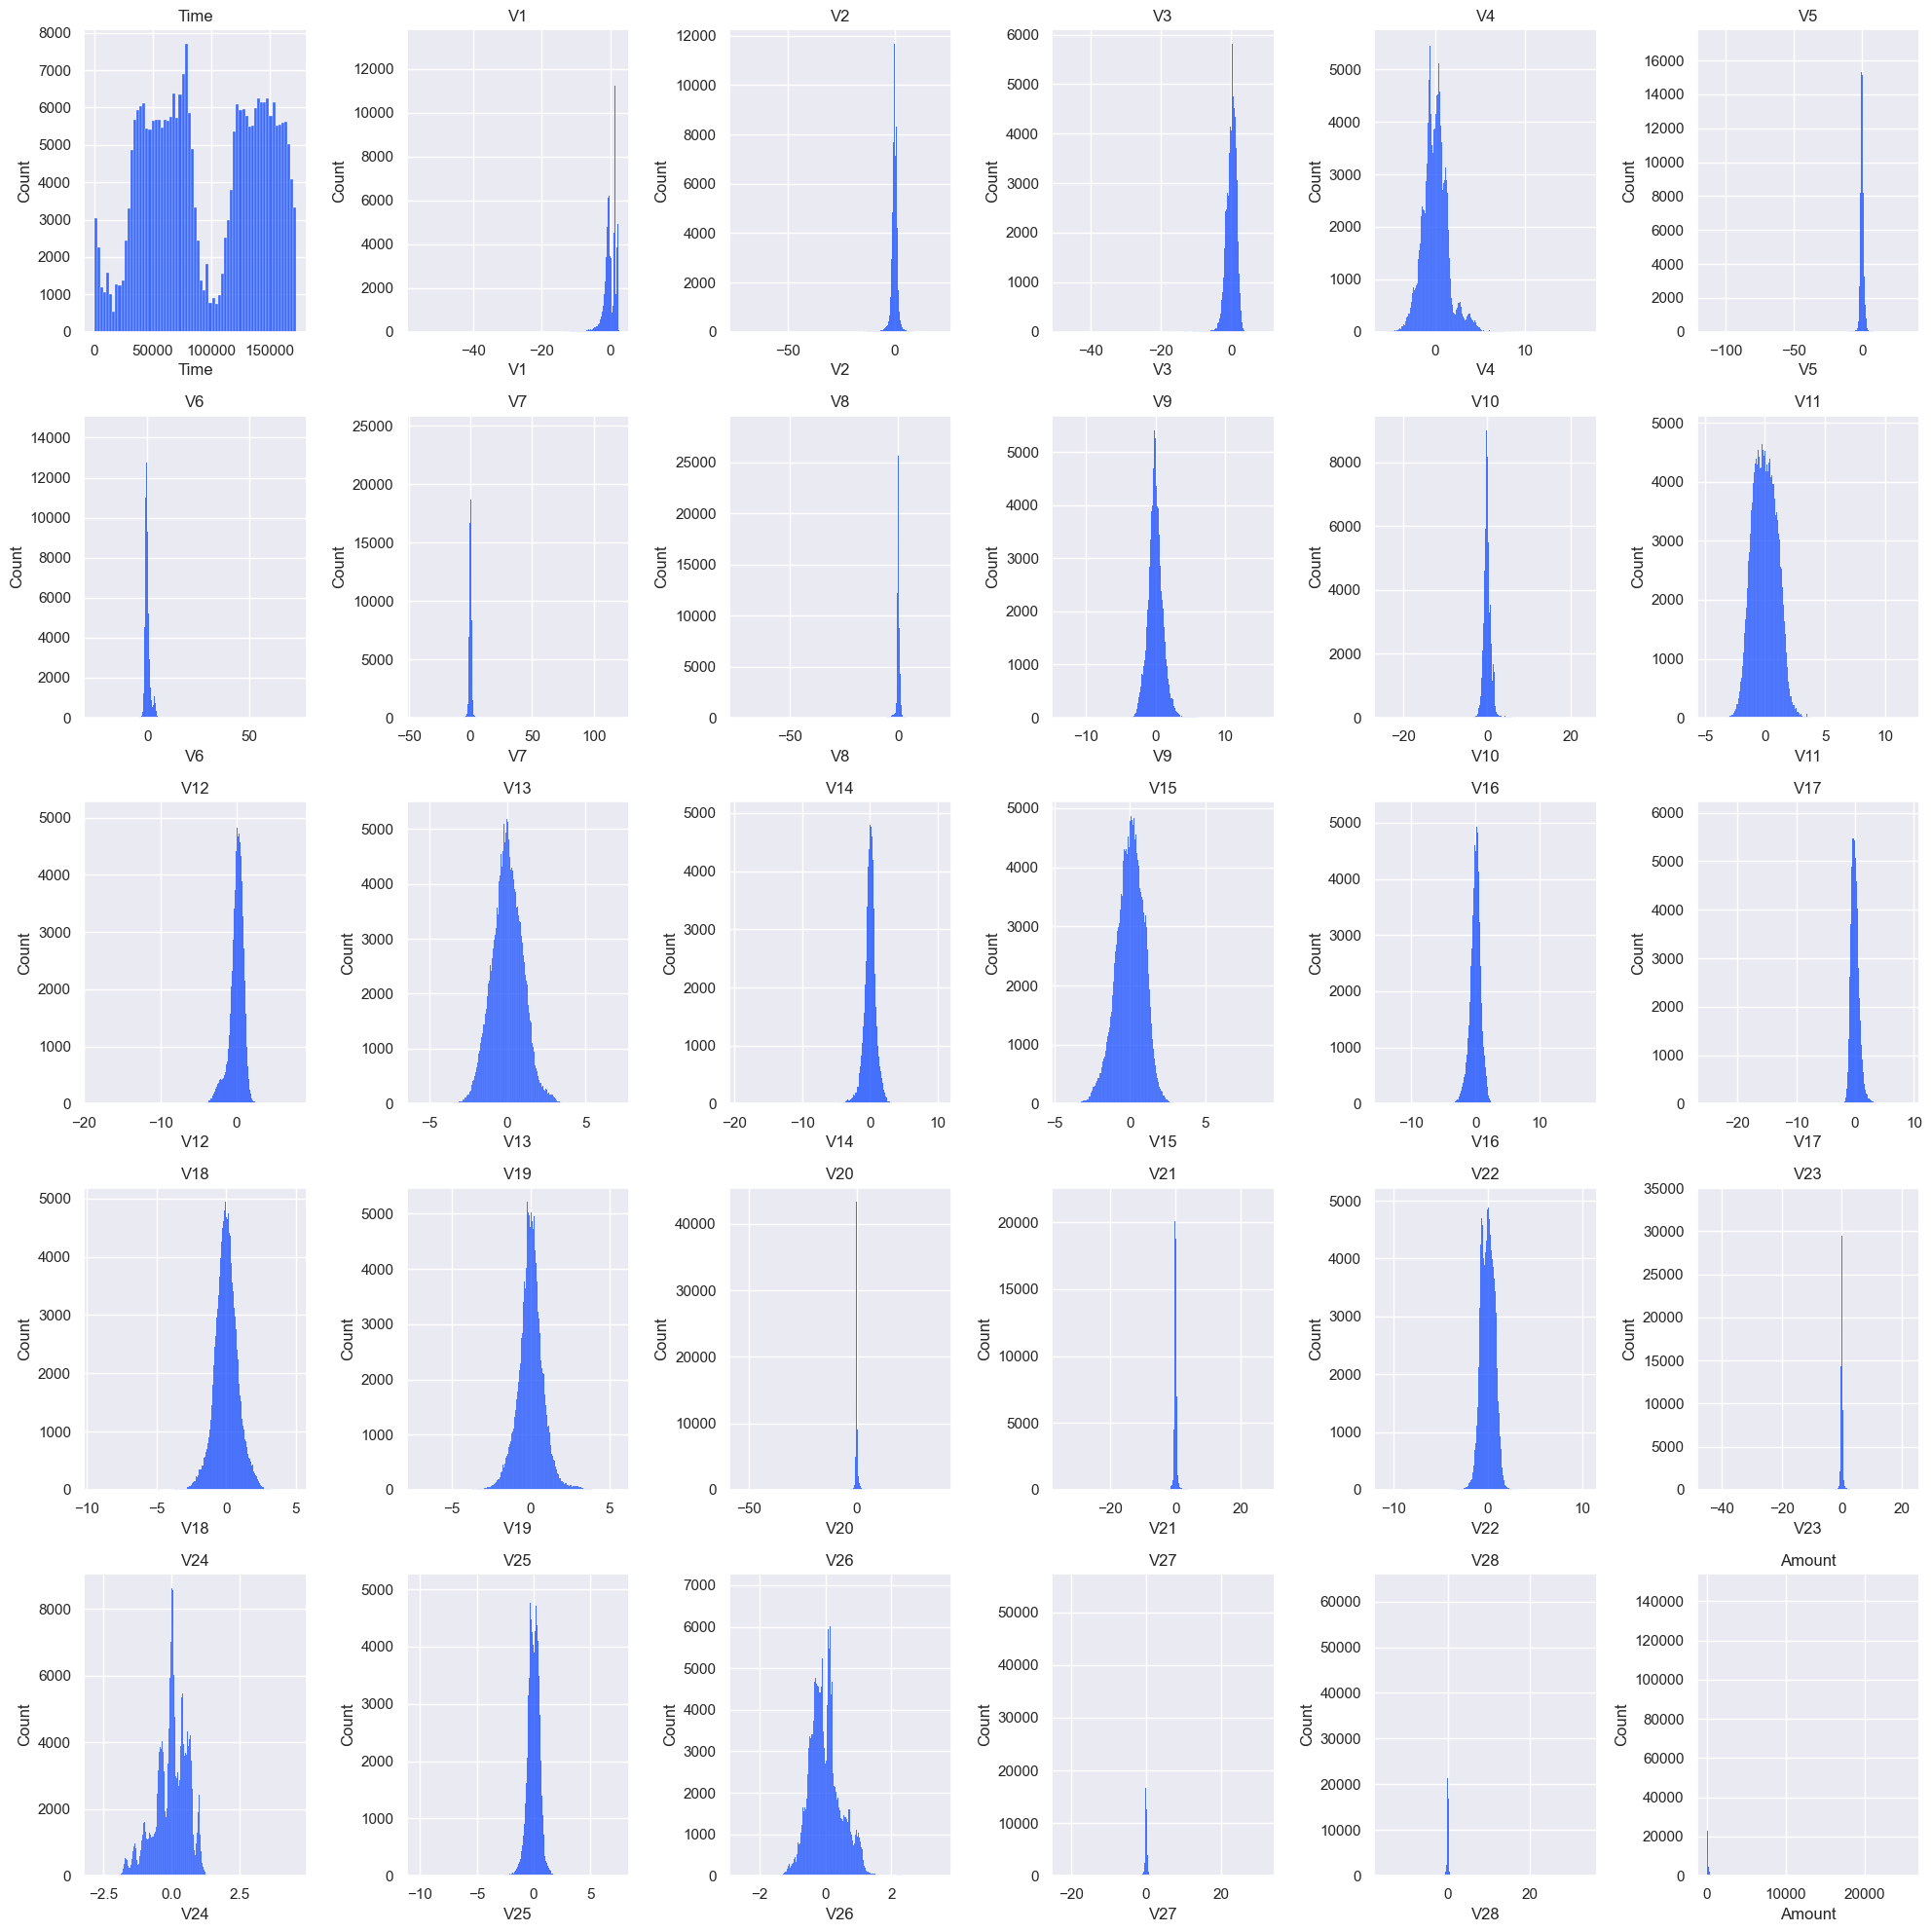

In [23]:
#Histograma das colunas

fig, ax = plt.subplots(5,6, figsize=(20, 20))

for ax, col in zip(ax.flatten(), df.select_dtypes(include="float").columns):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


ValueError: The following variable cannot be assigned with wide-form data: `hue`

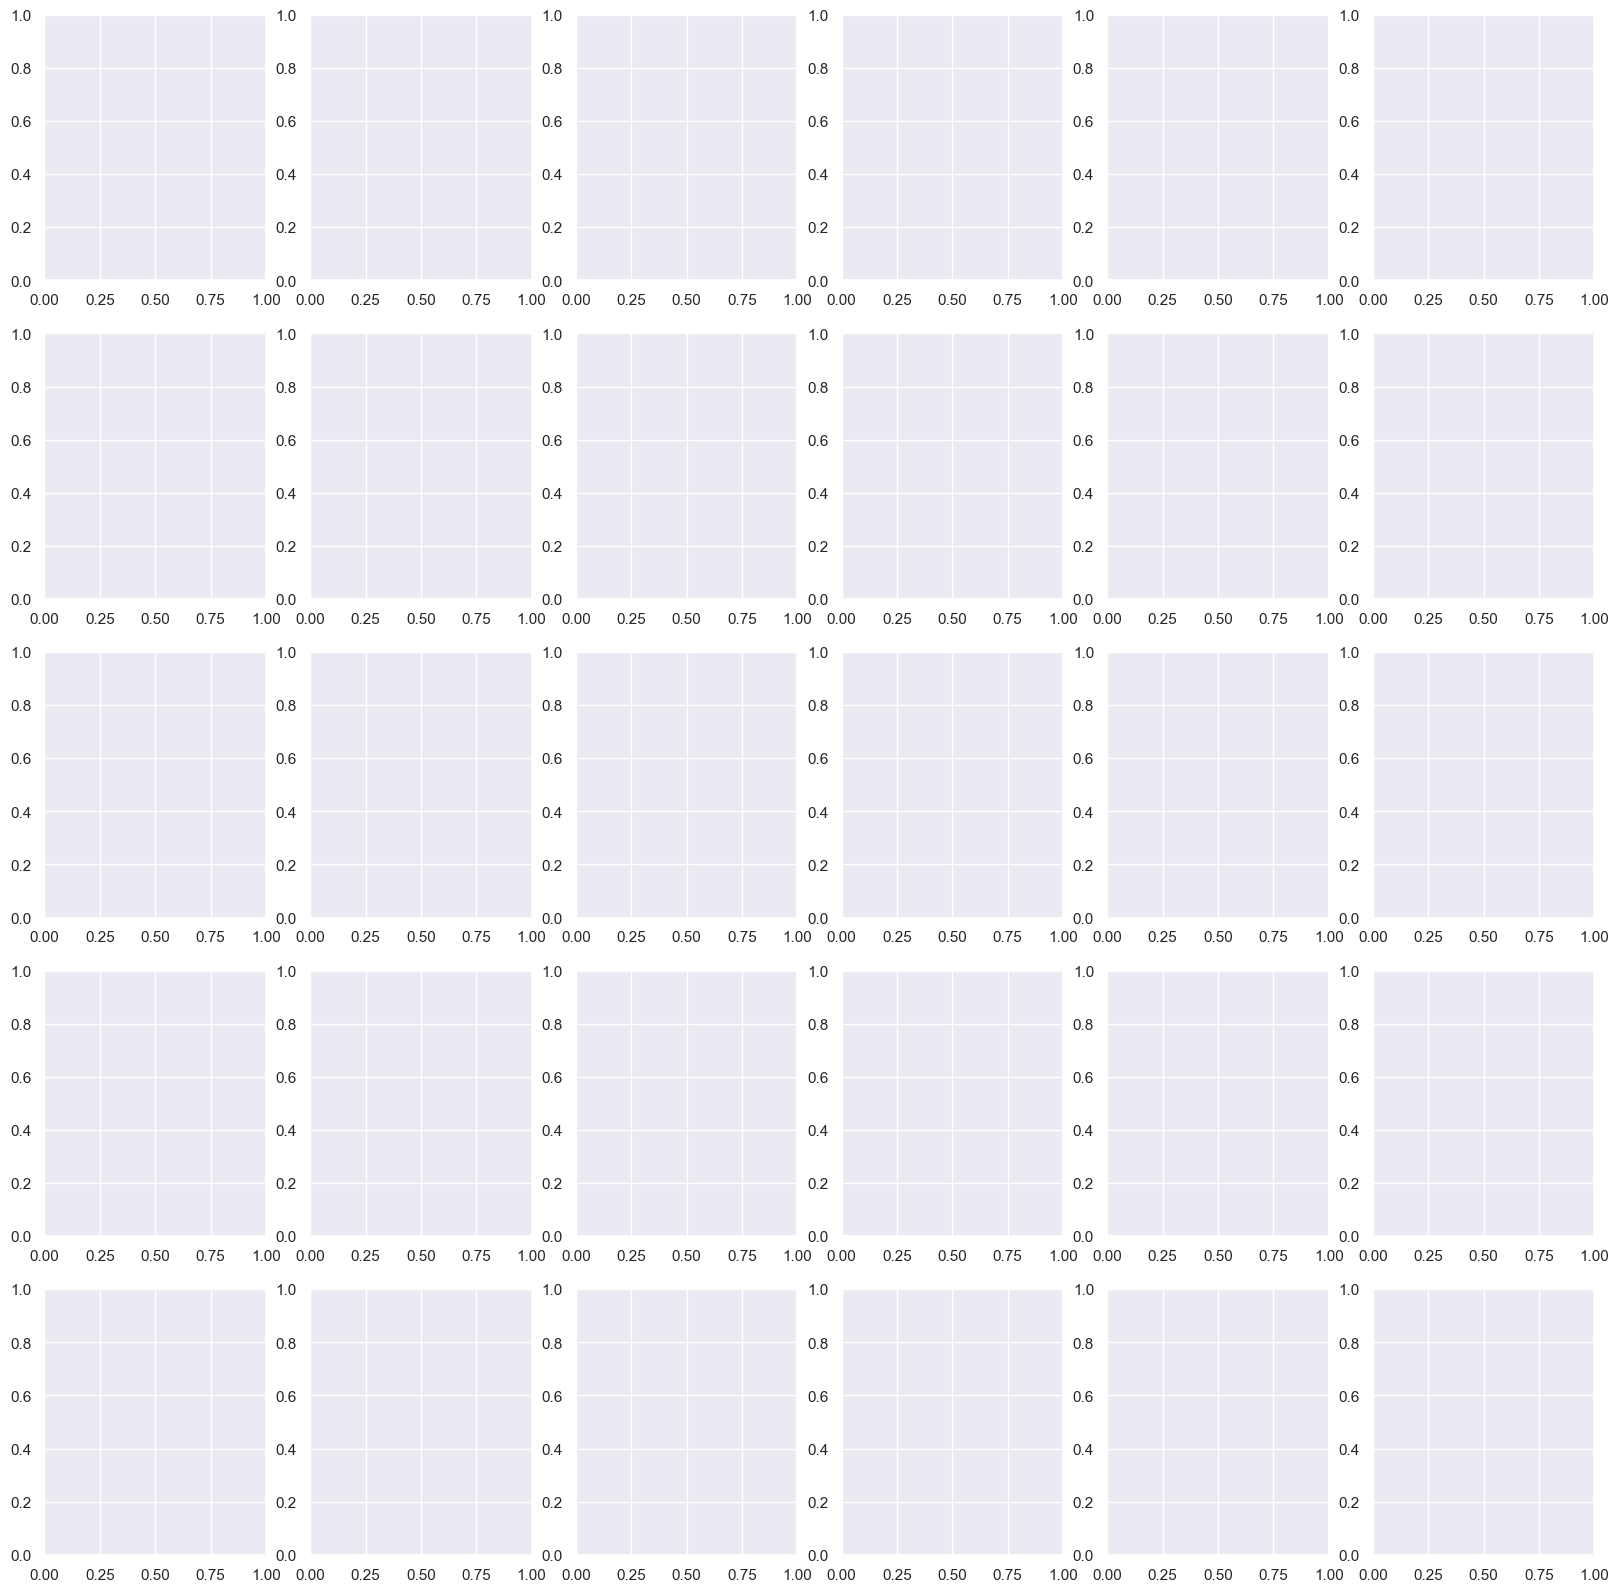

In [ ]:
#Histograma das colunas por classe

fig, ax = plt.subplots(5,6, figsize=(20, 20))

for ax, col in zip(ax.flatten(), df.select_dtypes(include="float").columns):
    #Histograma das colunas por classe

    fig, ax = plt.subplots(5,6, figsize=(20, 20))

    for ax, col in zip(ax.flatten(), df.select_dtypes(include="float").columns):
        sns.histplot(data=df, x=col, hue="Class", ax=ax, common_norm=False, stat="density")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()
    ax.set_title(col)
plt.tight_layout()
plt.show()